## 1. Install required packages

In [1]:
!unzip -q "Marine-Debris.v2i.yolov8.zip" -d .

replace ./README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
!ls

data.yaml		      README.dataset.txt   sample_data	train
Marine-Debris.v2i.yolov8.zip  README.roboflow.txt  test		valid


In [6]:
from pathlib import Path

DATASET_DIR = Path("/content")

dataset_config = DATASET_DIR / "data.yaml"

print("Dataset directory:", DATASET_DIR)
print("Dataset YAML:", dataset_config)

Dataset directory: /content
Dataset YAML: /content/data.yaml


In [7]:
print("data.yaml:", dataset_config.exists())
print("train:", (DATASET_DIR / "train").exists())
print("valid:", (DATASET_DIR / "valid").exists())
print("test:", (DATASET_DIR / "test").exists())

data.yaml: True
train: True
valid: True
test: True


In [8]:
import yaml

with open(dataset_config, "r") as f:
    config = yaml.safe_load(f)

print(config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 11, 'names': ['Bottle', 'Can', 'Chain', 'Drink-carton', 'Hook', 'Propeller', 'Shampoo-bottle', 'Standing-bottle', 'Tire', 'Valve', 'Wall'], 'roboflow': {'workspace': 'vedant-zhoqu', 'project': 'marine-debris-cqnuq', 'version': 2, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/vedant-zhoqu/marine-debris-cqnuq/dataset/2'}}


In [10]:
%pip install "ultralytics>=8.0.0,<9.0.0" pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.8 MB/s eta 0:00:00


## 2. Import libraries

In [11]:
from pathlib import Path
import shutil
import yaml
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

EXPECTED_CLASSES = [
    'Bottle', 'Can', 'Chain', 'Drink-carton', 'Hook', 'Propeller',
    'Shampoo-bottle', 'Standing-bottle', 'Tire', 'Valve', 'Wall'
]

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 3. Check dataset

In [13]:
from pathlib import Path
import yaml

DATASET_CANDIDATES = [
    Path('/content'),
    Path('data/marine-debris'),
    Path('Marine-Debris.v2i.yolov8'),
]

DATASET_DIR = next(
    (path for path in DATASET_CANDIDATES if (path / 'data.yaml').is_file()),
    None,
)

if DATASET_DIR is None:
    raise FileNotFoundError(
        'Dataset not found. Make sure data.yaml, train, valid, and test '
        'are available in the current Colab directory.'
    )

DATASET_DIR = DATASET_DIR.resolve()

with (DATASET_DIR / 'data.yaml').open(encoding='utf-8') as file:
    dataset_config = yaml.safe_load(file)

dataset_names = dataset_config.get('names')

if isinstance(dataset_names, dict):
    CLASS_NAMES = [
        dataset_names.get(index, dataset_names.get(str(index)))
        for index in range(dataset_config.get('nc', 0))
    ]
else:
    CLASS_NAMES = dataset_names

if CLASS_NAMES != EXPECTED_CLASSES:
    raise ValueError(
        f'Unexpected class names in data.yaml: {CLASS_NAMES}'
    )

if dataset_config.get('nc') != len(EXPECTED_CLASSES):
    raise ValueError(
        f"Expected {len(EXPECTED_CLASSES)} classes in data.yaml."
    )

dataset_config['path'] = str(DATASET_DIR)

split_folders = {
    'train': 'train',
    'val': 'valid',
    'test': 'test'
}

image_suffixes = {
    '.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'
}

for split, folder_name in split_folders.items():

    images_dir = DATASET_DIR / folder_name / 'images'
    labels_dir = DATASET_DIR / folder_name / 'labels'

    if not images_dir.is_dir() or not labels_dir.is_dir():
        raise FileNotFoundError(
            f'Missing images or labels for {folder_name}: {DATASET_DIR}'
        )

    dataset_config[split] = str(images_dir.resolve())

    image_count = sum(
        1
        for path in images_dir.iterdir()
        if path.suffix.lower() in image_suffixes
    )

    print(f'{folder_name}: {image_count} images')

TEST_IMAGES = DATASET_DIR / 'test' / 'images'

TEST_IMAGE_PATHS = sorted(
    path
    for path in TEST_IMAGES.iterdir()
    if path.suffix.lower() in image_suffixes
)

if not TEST_IMAGE_PATHS:
    raise FileNotFoundError(
        f'No test images found in {TEST_IMAGES}'
    )

print(f'Dataset: {DATASET_DIR}')
print(f'Classes: {CLASS_NAMES}')
print(f'Test images: {len(TEST_IMAGE_PATHS)}')

train: 1308 images
valid: 373 images
test: 187 images
Dataset: /content
Classes: ['Bottle', 'Can', 'Chain', 'Drink-carton', 'Hook', 'Propeller', 'Shampoo-bottle', 'Standing-bottle', 'Tire', 'Valve', 'Wall']
Test images: 187


## 4. Display class names

In [14]:
for class_id, class_name in enumerate(CLASS_NAMES):
    print(f'{class_id}: {class_name}')

0: Bottle
1: Can
2: Chain
3: Drink-carton
4: Hook
5: Propeller
6: Shampoo-bottle
7: Standing-bottle
8: Tire
9: Valve
10: Wall


## 5. Train YOLOv8

If GPU memory is insufficient, reduce `batch` from 16 to 8, then 4 or 2. Keep `imgsz=640`.

In [19]:
from pathlib import Path
import yaml

dataset_config = {
    "path": "/content",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",

    "nc": 11,
    "names": [
        "Bottle",
        "Can",
        "Chain",
        "Drink-carton",
        "Hook",
        "Propeller",
        "Shampoo-bottle",
        "Standing-bottle",
        "Tire",
        "Valve",
        "Wall"
    ]
}

yaml_path = Path("/content/data.yaml")

with open(yaml_path, "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

print("Created:", yaml_path)
print(yaml_path.read_text())

Created: /content/data.yaml
path: /content
train: train/images
val: valid/images
test: test/images
nc: 11
names:
- Bottle
- Can
- Chain
- Drink-carton
- Hook
- Propeller
- Shampoo-bottle
- Standing-bottle
- Tire
- Valve
- Wall



In [20]:
from pathlib import Path

for folder in [
    "/content/train/images",
    "/content/train/labels",
    "/content/valid/images",
    "/content/valid/labels",
    "/content/test/images",
    "/content/test/labels"
]:
    path = Path(folder)
    print(
        f"{'✓' if path.exists() else '✗'} {folder}",
        f"({len(list(path.iterdir()))} files)" if path.exists() else ""
    )

✓ /content/train/images (1308 files)
✓ /content/train/labels (1308 files)
✓ /content/valid/images (373 files)
✓ /content/valid/labels (373 files)
✓ /content/test/images (187 files)
✓ /content/test/labels (187 files)


In [21]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/runs/marine_debris",
    name="yolov8n",
    pretrained=True
)

best_checkpoint = Path(model.trainer.best)

print("Best model:", best_checkpoint)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=None, opset=None, optimize=False, opt

## 6. Validate model

In [23]:
!find /content -name "best.pt"

/content/runs/marine_debris/yolov8n/weights/best.pt


In [24]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/marine_debris/yolov8n/weights/best.pt"
)

print("Best model loaded successfully")

Best model loaded successfully


In [25]:
import os

print(os.path.exists("/content/data.yaml"))

True


In [26]:
from torch import device
validation_results = best_model.val(
    data="/content/data.yaml",
    split='val',
    imgsz=640,
    device=0
)
print(validation_results.results_dict)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1448.7±596.3 MB/s, size: 30.8 KB)
val: Scanning /content/valid/labels.cache... 373 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 373/373 120.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.1it/s 5.8s
                   all        373        778      0.927      0.928      0.945      0.707
                Bottle         82         90      0.938      0.978      0.992      0.757
                   Can         59         59      0.731      0.827      0.867       0.57
                 Chain         64         67      0.956      0.982      0.987      0.733
          Drink-carton         70         70      0.981          1      0.995      0.659
                  Hook         25         25      0.961

## 7. Test model

In [28]:
print(open("/content/data.yaml").read())

path: /content
train: train/images
val: valid/images
test: test/images
nc: 11
names:
- Bottle
- Can
- Chain
- Drink-carton
- Hook
- Propeller
- Shampoo-bottle
- Standing-bottle
- Tire
- Valve
- Wall



In [31]:
test_results = best_model.val(
    data="/content/data.yaml",
    split='test',
    imgsz=640,
    device=0
)
print(test_results.results_dict)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1034.2±290.2 MB/s, size: 30.7 KB)
val: Scanning /content/test/labels.cache... 187 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 52.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.3it/s 3.6s
                   all        187        411      0.947      0.927      0.967      0.744
                Bottle         48         55       0.93      0.927      0.972      0.743
                   Can         35         35      0.773      0.686      0.815      0.512
                 Chain         21         21          1      0.865      0.993      0.734
          Drink-carton         43         43      0.997          1      0.995      0.673
                  Hook         20         21      0.986  

## 8. Predict on test images

In [32]:
test_predictions = best_model.predict(
    source=str(TEST_IMAGES),
    imgsz=640,
    conf=0.25,
    save=True,
    project='/content/runs/marine_debris/predict',
    name='test',
    exist_ok=True
)
print(f'Predicted on {len(test_predictions)} test images.')
print('Annotated predictions saved in runs/marine_debris/predict/test')


image 1/187 /content/test/images/marine-debris-aris3k-1000_png.rf.0e492ee8534a254dfad84b84ec27da04.jpg: 640x640 1 Can, 1 Wall, 7.2ms
image 2/187 /content/test/images/marine-debris-aris3k-1001_png.rf.8919760b3a664d22938a868b2bf5dcd9.jpg: 640x640 1 Valve, 1 Wall, 8.0ms
image 3/187 /content/test/images/marine-debris-aris3k-1002_png.rf.d8eaa6d305a3eb07dcde829c7e21c9f5.jpg: 640x640 1 Shampoo-bottle, 1 Wall, 7.9ms
image 4/187 /content/test/images/marine-debris-aris3k-1004_png.rf.a845668ffaeace9fae983806de56429e.jpg: 640x640 1 Drink-carton, 1 Tire, 8.5ms
image 5/187 /content/test/images/marine-debris-aris3k-1010_png.rf.b9c00a145613f7d551b162b4251db63f.jpg: 640x640 1 Drink-carton, 1 Tire, 1 Wall, 9.2ms
image 6/187 /content/test/images/marine-debris-aris3k-1014_png.rf.97f7a3c269383504d83611e2a9466948.jpg: 640x640 1 Chain, 1 Drink-carton, 1 Wall, 11.0ms
image 7/187 /content/test/images/marine-debris-aris3k-1024_png.rf.108e20f6c6719ad37b02c00845c941f9.jpg: 640x640 2 Drink-cartons, 8.7ms
image 8/

## 9. Predict on one image


image 1/1 /content/test/images/marine-debris-aris3k-1000_png.rf.0e492ee8534a254dfad84b84ec27da04.jpg: 640x640 1 Can, 1 Wall, 23.8ms
Speed: 5.6ms preprocess, 23.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/marine_debris/predict/one_image


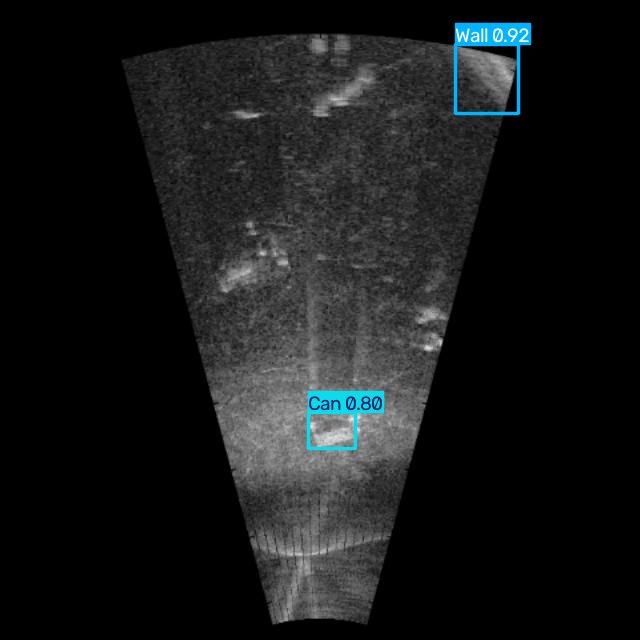

In [33]:
test_image = TEST_IMAGE_PATHS[0]
single_prediction = best_model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    save=True,
    project='/content/runs/marine_debris/predict',
    name='one_image',
    exist_ok=True
)[0]
display(Image.fromarray(single_prediction.plot()[:, :, ::-1]))

In [34]:
single_prediction = best_model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/content/runs/marine_debris/predict",
    name="one_image",
    exist_ok=True
)[0]


image 1/1 /content/test/images/marine-debris-aris3k-1000_png.rf.0e492ee8534a254dfad84b84ec27da04.jpg: 640x640 1 Can, 1 Wall, 7.2ms
Speed: 1.0ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/marine_debris/predict/one_image


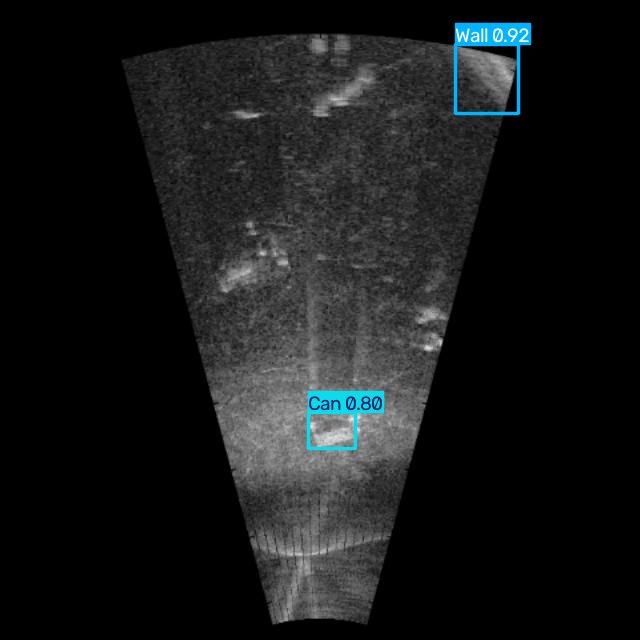

In [35]:
result_image = single_prediction.plot()

display(
    Image.fromarray(
        result_image[:, :, ::-1]
    )
)

In [36]:
for box in single_prediction.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = best_model.names[class_id]

    print(
        f"{class_name}: {confidence:.2%}"
    )

Wall: 91.88%
Can: 80.13%


Testing: /content/test/images/marine-debris-aris3k-1000_png.rf.0e492ee8534a254dfad84b84ec27da04.jpg

image 1/1 /content/test/images/marine-debris-aris3k-1000_png.rf.0e492ee8534a254dfad84b84ec27da04.jpg: 640x640 1 Can, 1 Wall, 8.4ms
Speed: 1.4ms preprocess, 8.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/marine_debris/predict/one_image


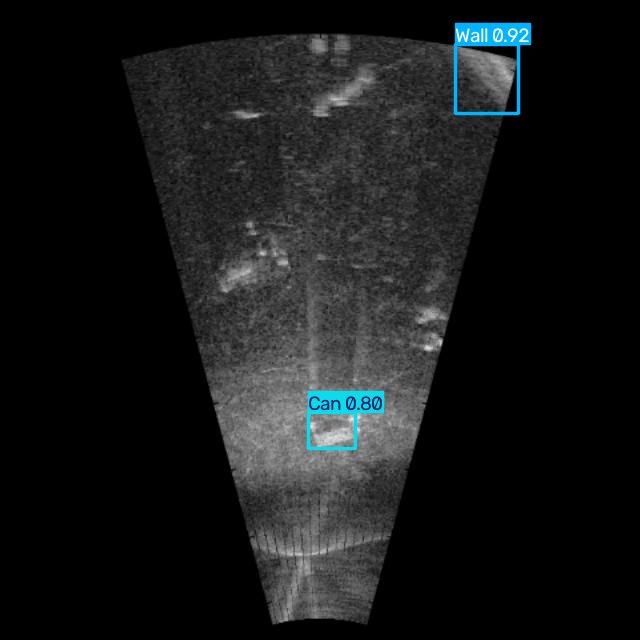


===== DETECTIONS =====
Wall: 91.88%
Can: 80.13%


In [37]:
from pathlib import Path
from PIL import Image
from IPython.display import display

# Test image directory
TEST_IMAGE_DIR = Path("/content/test/images")

# Find images
TEST_IMAGE_PATHS = sorted(
    TEST_IMAGE_DIR.glob("*")
)

if not TEST_IMAGE_PATHS:
    raise FileNotFoundError(
        f"No images found in {TEST_IMAGE_DIR}"
    )

# Select first image
test_image = TEST_IMAGE_PATHS[0]

print("Testing:", test_image)

# Prediction
single_prediction = best_model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/content/runs/marine_debris/predict",
    name="one_image",
    exist_ok=True
)[0]

# Display
result_image = single_prediction.plot()

display(
    Image.fromarray(
        result_image[:, :, ::-1]
    )
)

# Detection information
print("\n===== DETECTIONS =====")

for box in single_prediction.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = best_model.names[class_id]

    print(
        f"{class_name}: {confidence:.2%}"
    )

In [38]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/marine_debris/yolov8n/weights/best.pt"
)

In [39]:
results = best_model.val(
    data="/content/data.yaml",
    split="val",
    imgsz=640,
    device=0
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1494.8±652.1 MB/s, size: 29.9 KB)
val: Scanning /content/valid/labels.cache... 373 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 373/373 97.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.9it/s 4.9s
                   all        373        778      0.927      0.928      0.945      0.707
                Bottle         82         90      0.938      0.978      0.992      0.757
                   Can         59         59      0.731      0.827      0.867       0.57
                 Chain         64         67      0.956      0.982      0.987      0.733
          Drink-carton         70         70      0.981          1      0.995      0.659
                  Hook         25         25      0.961 

In [40]:
metrics = results.results_dict

print("Precision :", metrics["metrics/precision(B)"])
print("Recall    :", metrics["metrics/recall(B)"])
print("mAP@50    :", metrics["metrics/mAP50(B)"])
print("mAP@50-95 :", metrics["metrics/mAP50-95(B)"])

Precision : 0.9270899811242937
Recall    : 0.9278948829597006
mAP@50    : 0.9448793627051123
mAP@50-95 : 0.7067136158431754


In [41]:
print(f"Precision : {metrics['metrics/precision(B)'] * 100:.2f}%")
print(f"Recall    : {metrics['metrics/recall(B)'] * 100:.2f}%")
print(f"mAP@50    : {metrics['metrics/mAP50(B)'] * 100:.2f}%")
print(f"mAP@50-95 : {metrics['metrics/mAP50-95(B)'] * 100:.2f}%")

Precision : 92.71%
Recall    : 92.79%
mAP@50    : 94.49%
mAP@50-95 : 70.67%


In [42]:
precision = metrics["metrics/precision(B)"]
recall = metrics["metrics/recall(B)"]

f1 = 2 * (precision * recall) / (precision + recall)

print(f"F1 Score  : {f1:.4f}")
print(f"F1 Score  : {f1 * 100:.2f}%")

F1 Score  : 0.9275
F1 Score  : 92.75%


In [43]:
test_results = best_model.val(
    data="/content/data.yaml",
    split="test",
    imgsz=640,
    device=0
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1491.2±418.2 MB/s, size: 30.8 KB)
val: Scanning /content/test/labels.cache... 187 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 71.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.5it/s 3.4s
                   all        187        411      0.947      0.927      0.967      0.744
                Bottle         48         55       0.93      0.927      0.972      0.743
                   Can         35         35      0.773      0.686      0.815      0.512
                 Chain         21         21          1      0.865      0.993      0.734
          Drink-carton         43         43      0.997          1      0.995      0.673
                  Hook         20         21      0.986  

In [44]:
test_metrics = test_results.results_dict

print(f"Precision : {test_metrics['metrics/precision(B)'] * 100:.2f}%")
print(f"Recall    : {test_metrics['metrics/recall(B)'] * 100:.2f}%")
print(f"mAP@50    : {test_metrics['metrics/mAP50(B)'] * 100:.2f}%")
print(f"mAP@50-95 : {test_metrics['metrics/mAP50-95(B)'] * 100:.2f}%")

Precision : 94.68%
Recall    : 92.74%
mAP@50    : 96.69%
mAP@50-95 : 74.39%


In [47]:
from ultralytics import YOLO
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = YOLO("/content/runs/marine_debris/yolov8n/weights/best.pt")

results = model.val(
    data="/content/data.yaml",
    split="test",
    imgsz=640,
    device=0
)

# Per-class metrics
precision = results.box.p
recall = results.box.r
map50 = results.box.ap50
map5095 = results.box.ap

# F1 score
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

class_names = [model.names[i] for i in range(len(precision))]

df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "mAP@50": map50,
    "mAP@50-95": map5095
}, index=class_names)

print(df)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1420.2±421.1 MB/s, size: 29.7 KB)
val: Scanning /content/test/labels.cache... 187 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 56.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.2it/s 3.8s
                   all        187        411      0.947      0.927      0.967      0.744
                Bottle         48         55       0.93      0.927      0.972      0.743
                   Can         35         35      0.773      0.686      0.815      0.512
                 Chain         21         21          1      0.865      0.993      0.734
          Drink-carton         43         43      0.997          1      0.995      0.673
                  Hook         20         21      0.986  

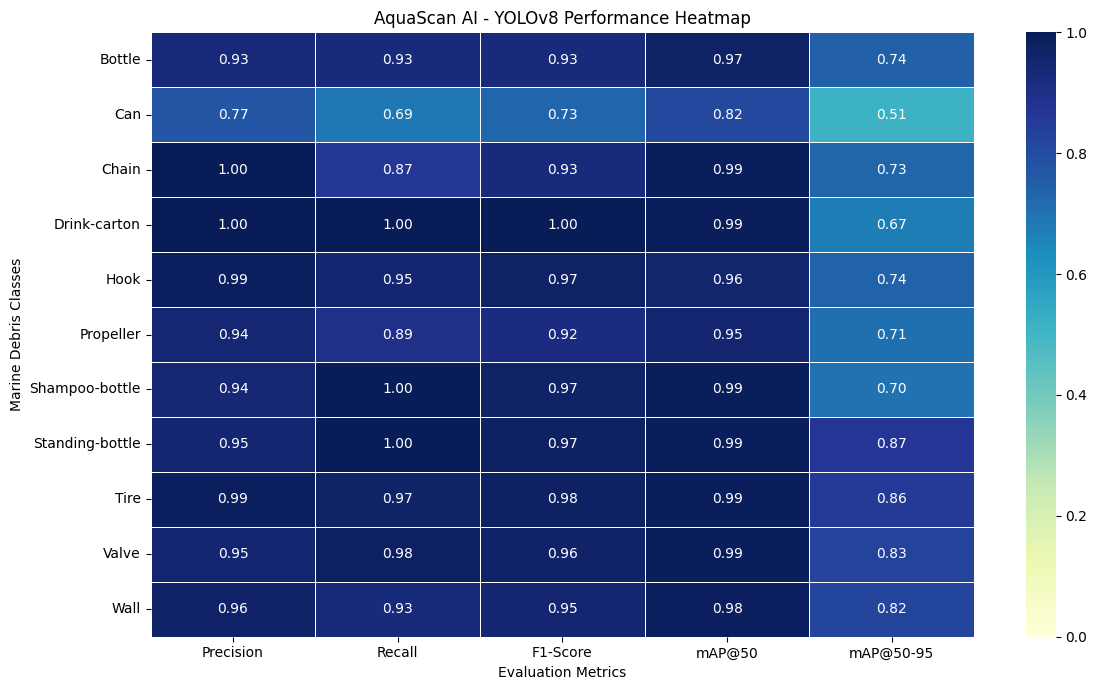

In [48]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("AquaScan AI - YOLOv8 Performance Heatmap")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Marine Debris Classes")

plt.tight_layout()
plt.show()

In [50]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns

# Load best trained model
model = YOLO("runs/marine_debris/yolov8n/weights/best.pt")

# Display model summary
print("\n========== MODEL SUMMARY ==========")
model.info()

# Evaluate model
results = model.val(
    data="/content/data.yaml",
    split="test",
    imgsz=640,
    device=0,
    plots=True
)

# Get metrics
metrics = results.results_dict

precision = metrics["metrics/precision(B)"]
recall = metrics["metrics/recall(B)"]
map50 = metrics["metrics/mAP50(B)"]
map5095 = metrics["metrics/mAP50-95(B)"]

f1 = 2 * (precision * recall) / (precision + recall)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Precision   : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall      : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score    : {f1:.4f} ({f1*100:.2f}%)")
print(f"mAP@50      : {map50:.4f} ({map50*100:.2f}%)")
print(f"mAP@50-95   : {map5095:.4f} ({map5095*100:.2f}%)")


========== MODEL SUMMARY ==========
Model summary: 129 layers, 3,012,993 parameters, 0 gradients, 8.2 GFLOPs
Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1348.1±324.8 MB/s, size: 30.7 KB)
val: Scanning /content/test/labels.cache... 187 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 49.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.7it/s 4.5s
                   all        187        411      0.947      0.927      0.967      0.744
                Bottle         48         55       0.93      0.927      0.972      0.743
                   Can         35         35      0.773      0.686      0.815      0.512
                 Chain         21         21          1      0.865      0.993      0.734
          Drink-carton         43   

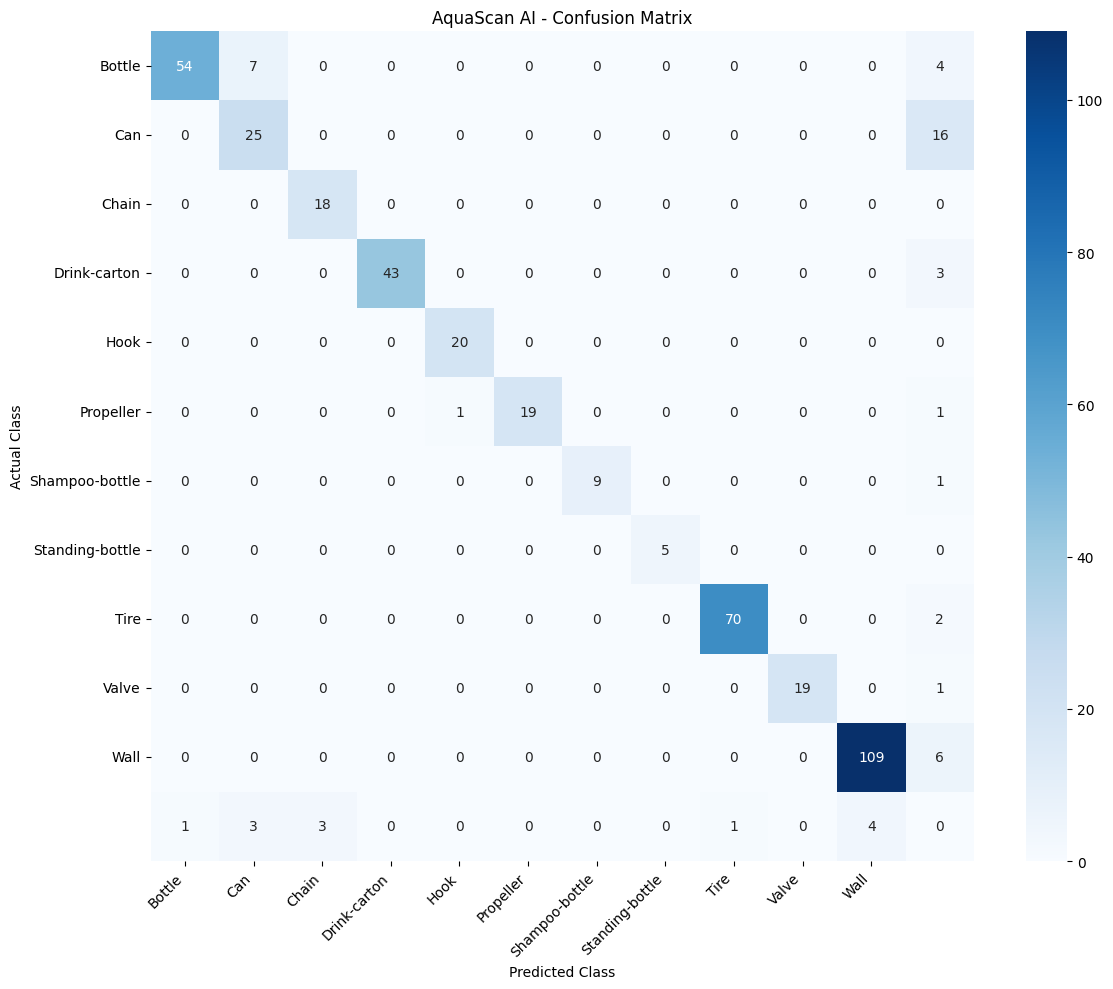

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = results.confusion_matrix.matrix

class_names = [
    "Bottle",
    "Can",
    "Chain",
    "Drink-carton",
    "Hook",
    "Propeller",
    "Shampoo-bottle",
    "Standing-bottle",
    "Tire",
    "Valve",
    "Wall"
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("AquaScan AI - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

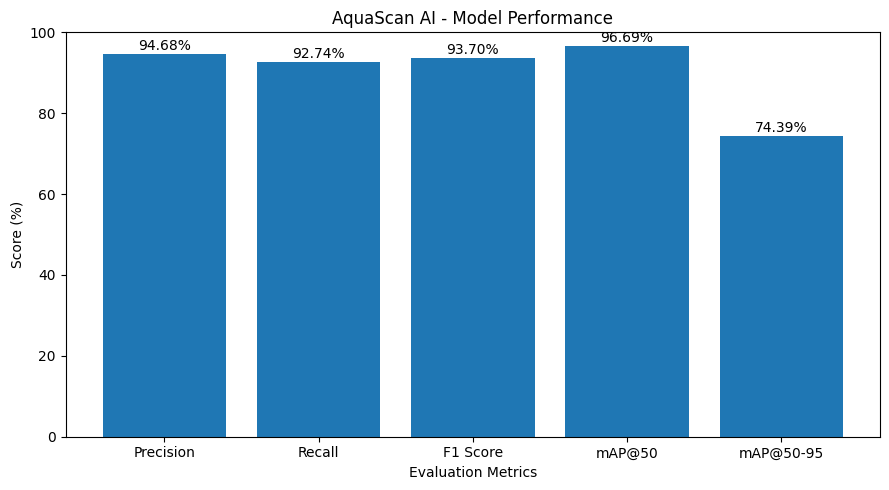

In [52]:
metrics_names = [
    "Precision",
    "Recall",
    "F1 Score",
    "mAP@50",
    "mAP@50-95"
]

metric_values = [
    precision,
    recall,
    f1,
    map50,
    map5095
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metrics_names,
    [x * 100 for x in metric_values]
)

plt.ylabel("Score (%)")
plt.xlabel("Evaluation Metrics")
plt.title("AquaScan AI - Model Performance")

plt.ylim(0, 100)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value * 100 + 1,
        f"{value*100:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 10. Save best.pt

In [54]:
model_directory = Path('models')
model_directory.mkdir(parents=True, exist_ok=True)
final_model_path = model_directory / 'marine_debris_yolov8n_best.pt'
shutil.copy2(best_checkpoint, final_model_path)
print(f'Saved trained model to: {final_model_path.resolve()}')

Saved trained model to: /content/models/marine_debris_yolov8n_best.pt


In [55]:
from google.colab import files

files.download("/content/runs/marine_debris/yolov8n/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
!find /content/runs -name "best.pt"

/content/runs/marine_debris/yolov8n/weights/best.pt


In [57]:
!zip -r /content/marine_debris_training.zip /content/runs/marine_debris

  adding: content/runs/marine_debris/ (stored 0%)
  adding: content/runs/marine_debris/yolov8n/ (stored 0%)
  adding: content/runs/marine_debris/yolov8n/results.csv (deflated 62%)
  adding: content/runs/marine_debris/yolov8n/BoxR_curve.png (deflated 7%)
  adding: content/runs/marine_debris/yolov8n/train_batch1.jpg (deflated 16%)
  adding: content/runs/marine_debris/yolov8n/val_batch2_pred.jpg (deflated 22%)
  adding: content/runs/marine_debris/yolov8n/confusion_matrix_normalized.png (deflated 17%)
  adding: content/runs/marine_debris/yolov8n/val_batch1_pred.jpg (deflated 23%)
  adding: content/runs/marine_debris/yolov8n/weights/ (stored 0%)
  adding: content/runs/marine_debris/yolov8n/weights/best.pt (deflated 10%)
  adding: content/runs/marine_debris/yolov8n/weights/last.pt (deflated 10%)
  adding: content/runs/marine_debris/yolov8n/val_batch1_labels.jpg (deflated 23%)
  adding: content/runs/marine_debris/yolov8n/train_batch3282.jpg (deflated 17%)
  adding: content/runs/marine_debris/

In [58]:
from google.colab import files

files.download("/content/marine_debris_training.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>